# Intro

* Where Attention fits into the feedforward sweep
* Different tokenizers use slightly different naming conventions
* More about the $QK^T$ matrix in Attention

# Code

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn import functional as F

In [2]:
#n load GPT2 tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Hyperparameters

In [4]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_added_tokens_decoder',
 '_added_tokens_encoder',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_merges',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 

In [5]:
# data hyperparameters
seq_len = 8
n_vocab = tokenizer.vocab_size

# model hyperparameters
embed_dim = 2**6

# training hyperparameters
batch_size = 5

# Model

In [18]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # embedding matrices
    self.embedding = nn.Embedding(n_vocab, embed_dim)
    self.positions = nn.Embedding(seq_len, embed_dim)

    # final output linear layer (unembeddings)
    self.final_linear = nn.Linear(embed_dim, n_vocab, bias = False)

    # initialize the k,q,v matrices for attention
    self.layer_norm_A = nn.LayerNorm(embed_dim)
    self.key          = nn.Linear(embed_dim, embed_dim, bias = False)
    self.query        = nn.Linear(embed_dim, embed_dim, bias = False)
    self.value        = nn.Linear(embed_dim, embed_dim, bias = False)
    self.W0           = nn.Linear(embed_dim, embed_dim)

    # the final output layer is tied to the token embedding
    self.final_linear.weight = nn.Parameter(self.embedding.weight)

  def forward(self, tok_x):

    # create the token+position embedding
    token_embed = self.embedding(tok_x)
    posit_embed = self.positions(torch.arange(tok_x.shape[-1])) # [num_tokens, embed_dim]

    # their sum is the output of the embeddings
    x = token_embed + posit_embed # [batch, num_tokens, embedding_dims]

    ## n --- attention sublayer begins here
    # layernorm before attention
    x = self.layer_norm_A(x)

    # attention algo
    k = self.key(x)
    q = self.query(x)
    v = self.value(x)

    qk = q@k.transpose(-2,-1) # dor product between query and keys
    qk_scaled = qk * embed_dim**-.5
    past_mask = torch.tril(torch.ones(x.shape[0], seq_len, seq_len))
    qk_scaled[past_mask == 0] = -torch.inf
    qk_softmax = F.softmax(qk_scaled, dim = -1)
    y = qk_softmax@v

    y *= self.W0(y)
    #n --- end attention

    # MLP sublayer would be here (next version of the model)

    # final output transformation (unembeddings)
    y = self.final_linear(y) / np.sqrt(embed_dim)

    return y, (past_mask, qk_scaled, qk_softmax) # output some attention matrices for inspection (hooks are better in real models)

  def generate(self, tok_x, temperature = 1, n_new_tokens = 50):

    # tok_x is [batch, tokens]

    for _ in range(n_new_tokens):

        # get predictions, but only from the past seq_len tokens
        x = self(tok_x[:, -seq_len:])[0] # [batch, seq_len, n_vocab]

        # extract the final token to predict the next
        x = x[:,-1,:] # [batch, n_vocab]

        # apply softmax to get prbability values over all tokens in the vocab
        probs = F.softmax(x/temperature, dim = -1) #[batch, n_vocab]

        # probabilistically sample from the distribution
        tok_x_next = torch.multinomial(probs, num_samples = 1) # [batch, 1]

        # append
        tok_x = torch.cat((tok_x, tok_x_next), dim = 1) # [batch, (tokens+1)]

    return tok_x

# Logis

In [19]:
# create data
tokens = tokenizer.encode('I prefer oat milk in my coffee.')
X = torch.tensor(tokens[:-1]).unsqueeze(0)
y = torch.tensor(tokens[1:]).unsqueeze(0)

print(X.shape)
print(y.shape)

torch.Size([1, 8])
torch.Size([1, 8])


In [20]:
model = Model()
out, attn = model(X)

print(out.shape)

torch.Size([1, 8, 50257])


In [23]:
print('Time-causal mask:\n', attn[0])
print('\nqk_scaled:\n', attn[1])
print('\nqk_softmax:\n',attn[2])

Time-causal mask:
 tensor([[[1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]])

qk_scaled:
 tensor([[[-0.1538,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [ 0.1618,  0.0289,    -inf,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [-0.3012, -0.8174,  0.5492,    -inf,    -inf,    -inf,    -inf,
             -inf],
         [-0.3511,  0.3147,  0.0515, -0.4417,    -inf,    -inf,    -inf,
             -inf],
         [ 0.1182,  0.2600, -0.1430,  0.0436, -0.1912,    -inf,    -inf,
             -inf],
         [ 0.0723,  0.1393, -0.5489, -0.4035,  0.4597,  0.3996,    -inf,
             -inf],
         [ 0.2060,  0.0933, -0.2183,  0.6847, -0.2889, -0.0443, 

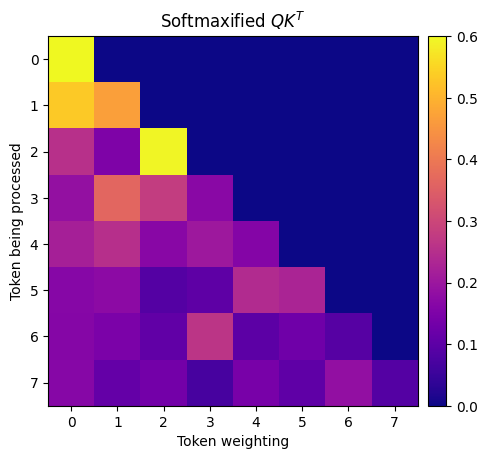

In [26]:
plt.imshow(attn[2].detach().squeeze(), vmin = 0, vmax = .6, cmap = 'plasma')
plt.gca().set(xlabel='Token weighting', ylabel = 'Token being processed', title = 'Softmaxified $QK^T$')
plt.colorbar(pad = .02)
plt.show()

In [27]:
# sanity-check
attn[2].detach().squeeze().sum(dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

# Generate Text

In [28]:
# start with some new tokens
text = "When I grow up, I want to be a"
tokens = tokenizer.encode(text)
tokens = torch.tensor(tokens).unsqueeze(0)

generated_tokens = model.generate(tokens, temperature=2, n_new_tokens = 10)[0]

tokenizer.decode(generated_tokens.tolist())

'When I grow up, I want to be a interfereNich Ji icy socket Nicola resulteduckland1007 reserve'

Repeat with different temperature values

In [29]:
temps = [.2, .7, 1, 2, 10]

for T in temps:
  tokz = model.generate(tokens, temperature= T, n_new_tokens=10)
  tokz = tokz[0].tolist()
  print(f'Temp = {T}:\n {tokenizer.decode(tokz)}\n')

Temp = 0.2:
 When I grow up, I want to be a NYCConservative beautifullyippi conversions teachingomers variant formats takes

Temp = 0.7:
 When I grow up, I want to be a composer Lan careful beaut Veg Pokemonifact haltIsa reciprocal

Temp = 1:
 When I grow up, I want to be a intuitionikan Creatures Heroicxit Gilablishment cafeteriastorage HMS

Temp = 2:
 When I grow up, I want to be aEV Falconsr Answeralam Once timeless nonviolentSalt fools

Temp = 10:
 When I grow up, I want to be a Environmental notationilarch anyン�� bowls extravagant rusher

